In [1]:
%load_ext autoreload
%autoreload 2

In [10]:
import os
import sys

sys.path.append("..")

import matplotlib.cm as cm
import numpy as np
import torch
from matplotlib import pyplot as plt

from src.distributions import StandardNormalSampler, SwissRollSampler
from src.light_gcot import LightGCOT
from src.light_sb import LightSB

In [3]:
models = []
models_SB = []

for eps in [0.002]:
    EXP_NAME = f"LightGCOT_Swiss_Roll_EPSILON_{eps}"
    OUTPUT_PATH = "../checkpoints/{}".format(EXP_NAME)
    D = LightGCOT(
        x_dim=2,
        y_dim=2,
        n_potentials=500,
        m_potentials=1,
        epsilon=eps,
        A_diagonal_init=0.0001,
        is_B_diagonal=True,
    )
    D.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D.pt")))
    models.append(D)

    EXP_NAME_SB = f"LightSB_Swiss_Roll_EPSILON_{eps}"
    OUTPUT_PATH_SB = "../checkpoints/{}".format(EXP_NAME_SB)
    D_SB = LightSB(dim=2, n_potentials=500, epsilon=eps, sampling_batch_size=128, is_diagonal=True)
    D_SB.load_state_dict(torch.load(os.path.join(OUTPUT_PATH_SB, f"D.pt")))

    models_SB.append(D_SB)

In [4]:
X_sampler = StandardNormalSampler(dim=2, device="cpu")
Y_sampler = SwissRollSampler(dim=2, device="cpu")

In [9]:
NUM_STARTING_POINTS = 4

In [35]:
colors_chosen = cm.rainbow(np.linspace(0.1, 0.4, NUM_STARTING_POINTS))

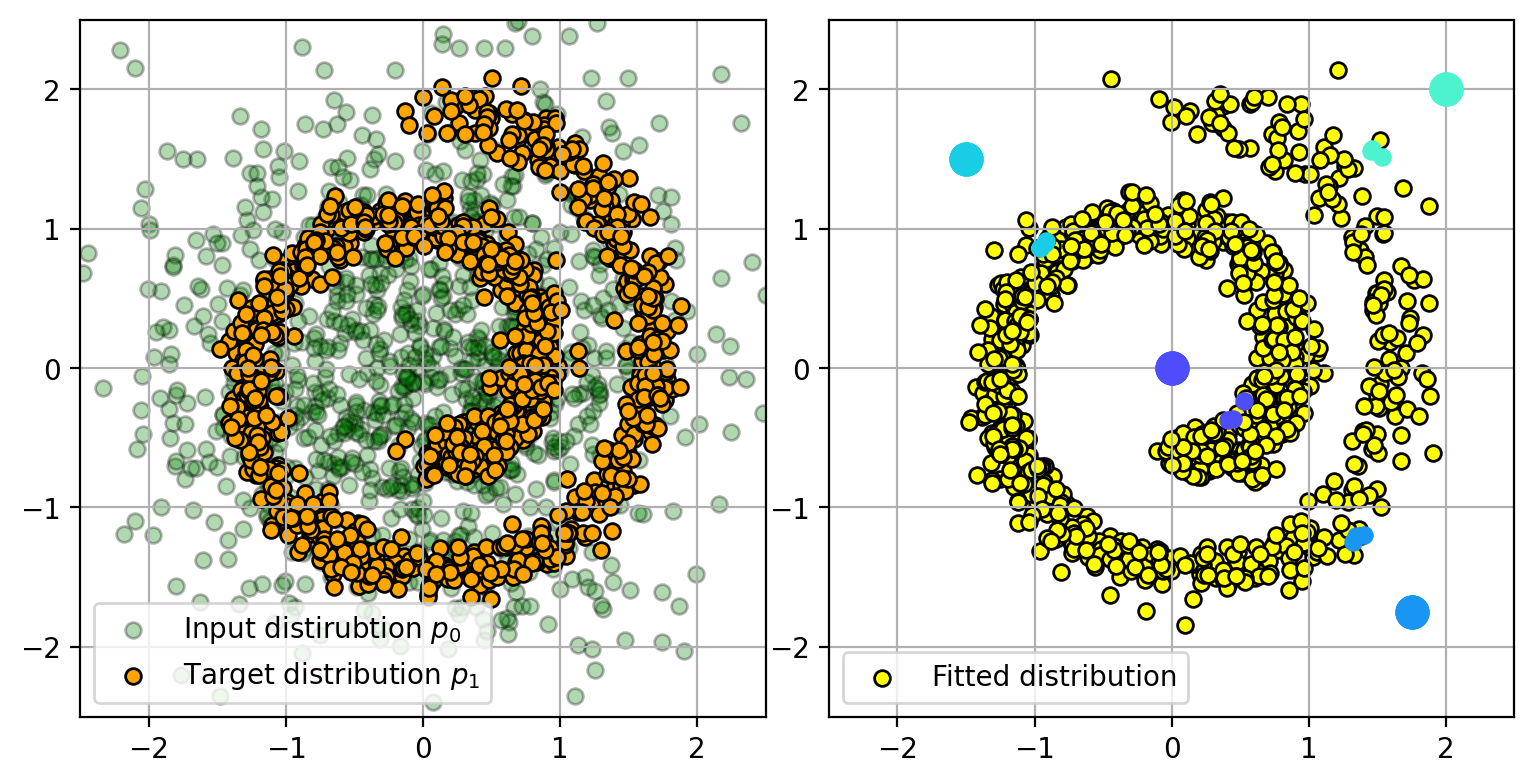

In [38]:
SEED = 12

torch.manual_seed(SEED)
np.random.seed(SEED)

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.75), dpi=200)

for ax in axes:
    ax.grid(zorder=-20)

x_samples = X_sampler.sample(1024)
y_samples = Y_sampler.sample(1024)
tr_samples = torch.tensor([[0.0, 0.0], [1.75, -1.75], [-1.5, 1.5], [2, 2]])

tr_samples = tr_samples[None].repeat(3, 1, 1).reshape(12, 2)

axes[0].scatter(
    x_samples[:, 0], x_samples[:, 1], alpha=0.3, c="g", s=32, edgecolors="black", label=r"Input distirubtion $p_0$"
)
axes[0].scatter(
    y_samples[:, 0], y_samples[:, 1], c="orange", s=32, edgecolors="black", label=r"Target distribution $p_1$"
)

for ax, model in zip(axes[1:], models):
    y_pred = model(x_samples)

    ax.scatter(y_pred[:, 0], y_pred[:, 1], c="yellow", s=32, edgecolors="black", label="Fitted distribution", zorder=1)

    tr_samples_pred = model(tr_samples)
    for i in range(3):
        for j, (point, point_pred) in enumerate(
            zip(
                tr_samples[i * NUM_STARTING_POINTS : (i + 1) * NUM_STARTING_POINTS],
                tr_samples_pred[i * NUM_STARTING_POINTS : (i + 1) * NUM_STARTING_POINTS],
            )
        ):
            ax.scatter(
                point[0],
                point[1],
                color=colors_chosen[j],
                s=128,
                # label=r"Trajectory start ($x \sim p_0$)",
                zorder=3,
            )
            ax.scatter(
                point_pred[0],
                point_pred[1],
                color=colors_chosen[j],
                s=32,
                # label=r"Trajectory end ($x \sim p_1$)",
                zorder=3,
            )


for ax in axes:
    ax.set_xlim([-2.5, 2.5])
    ax.set_ylim([-2.5, 2.5])
    ax.legend(loc="lower left")

fig.tight_layout(pad=0.1)